# ESP algorithm with NSGA II
1. implementing with one optimization function, maximizing the overall score of the players and see the pareto front solutions.

In [4]:
import os
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "portugal_squad.db"
SRC_DIR = BASE_DIR / "src"
sys.path.append(str(BASE_DIR))

In [5]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from src.esp_solver import SquadOptimizatoinProblem, MicroRoleAwareDuplicateRepair
# from src.formations import FORMATIONS_SPEC, MICRO_TO_SUBROLE, GLOBAL_ROLE_MAPING

from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling
from pymoo.core.problem import ElementwiseProblem, Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

In [6]:
player_data_file = BASE_DIR /"data"/"final_squad_cleaned.json"

with open(player_data_file, "r") as f:
    player_squad = json.load(f) 

budget = 9_00_000

#define the problem
problem = SquadOptimizatoinProblem(player_squad,budget=budget)

# configure the algorithm
algorithm = NSGA2(pop_size=50,
                    sampling= IntegerRandomSampling(),
                    crossover=TwoPointCrossover(prob=0.5),
                    mutation =PolynomialMutation(eta=100,prob=5/11),
                    repair = MicroRoleAwareDuplicateRepair(),
                    eliminate_duplicates=True)

# run optimization
result = minimize( problem,
                    algorithm,
                    ('n_gen', 500),
                    seed=1,
                    verbose=True
                        )

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       50 |      2 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      100 |      5 |  0.000000E+00 |  0.000000E+00 |  0.5384615385 |         ideal
     3 |      150 |      9 |  0.000000E+00 |  0.000000E+00 |  0.0614035088 |         ideal
     4 |      200 |     13 |  0.000000E+00 |  0.000000E+00 |  0.2771084337 |         ideal
     5 |      250 |      7 |  0.000000E+00 |  0.000000E+00 |  0.1034482759 |         ideal
     6 |      300 |     11 |  0.000000E+00 |  0.000000E+00 |  0.0807692308 |         ideal
     7 |      350 |      8 |  0.000000E+00 |  0.000000E+00 |  0.2432432432 |         ideal
     8 |      400 |      8 |  0.000000E+00 |  0.000000E+00 |  0.1428571429 |         ideal
     9 |      450 |      8 |  0.000000E+00 |  0.000000E+00 |  0.3303571429 |         ideal
    10 |      500 |      9 |  0.000000E+00 |  0.000000E+00 |  0.3132530121 |         ideal

In [ ]:
import numpy as np
import pandas as pd

# Disable truncation across NumPy, Pandas, and IPython
np.set_printoptions(threshold=np.inf, linewidth=1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
if result.X.ndim == 1:
    result.X = result.X[np.newaxis, :]

# print('length of results ', result.X)
# # 4. Extract results
print("Number of solutions:", len(result.F))
print("\nBest teams (Pareto front):")
dfs=[]
total_cost = []

for i in range(2,5):

    print(f'Team_{i+1}:')
    genome = result.X[i]
    # quit()
    objectives = result.F[i]
    # print(genome)
    unique = set(genome[1:])
    
    if len(unique)==10:      
        continue
    elif len(unique) < 10:
        print(f' contains duplicate players')
    

    # Decode genome to actual team
    idx=1
    gk = problem.players_by_pos['GK'][int(genome[0])]
    outfield_players = []
    outfield_players_role = []

    roles_genome = problem.assigned_roles[tuple(genome)]

    # print(problem.assigned_roles[tuple(genome)])
    # quit()
    # print(roles_genome)
    # print(genome)

    for pos in ['DF','MF','FW']:
        for _ in range(problem.formation[pos]):
            outfield_players.append(problem.players_by_pos[pos][int(genome[idx])])
            try:
                outfield_players_role.append(roles_genome[idx])
            except:
                print(idx,genome[idx],roles_genome)
                quit()
            idx+=1

    team = [gk] + outfield_players
    team_role = ['GK']+outfield_players_role
    # team selected        
    print(f"\nTeam {i+1}:")
    print(f" Total rating: {-objectives[0]:.1f}")
    # print(f"  Overall: {-objectives[1]:.1f}")
    # print(f"  Potential: {-objectives[2]:.1f}")
    print(f"  Attack: {-objectives[1]:.1f}")
    print(f"  Defense: {-objectives[2]:.1f}")
    # print(f"  GK: {-objectives[4]:.1f}")
    print(f"  Players: {[p['Name'] for p in team]}")
    rows = []
    print(genome)
    for idx,p in enumerate(team):
        rows.append({
            "Name": p["Name"],
            "Position": p["GlobalPos"],
            "Overall": p["Overall"],
            'role':team_role[idx],
            'Wage' : p['WageEUR'],
            'attack':p['attack_score'],
            'defense':p['defense_score']
        })

    df = pd.DataFrame(rows)
    dfs.append(df)
    # print(df)
    print(f"Total cost of the team: ",sum(df['Wage']))
    cost = sum(df['Wage'])
    total_cost.append(cost)

Number of solutions: 50

Best teams (Pareto front):
Team_3:
 contains duplicate players

Team 3:
 Total rating: 936.0
  Attack: 817.8
  Defense: 758.0
  Players: ['A. Cragno', 'G. Kondogbia', 'Melvin Parrela', 'M. Acuña', 'Jesús Navas', 'C. Nkunku', 'J. Kimmich', 'S. Mané', 'L. Ocampos', 'L. Messi', 'L. Martínez']
[ 55  81 174  17  52  25   5   4 115   0  17]
Total cost of the team:  877000
Team_4:

Team 4:
 Total rating: 949.0
  Attack: 788.2
  Defense: 761.6
  Players: ['A. Cragno', 'N. Süle', 'F. Tomori', 'A. Davies', 'Jesús Navas', 'C. Nkunku', 'J. Kimmich', 'L. Goretzka', 'L. Insigne', 'L. Messi', 'L. Martínez']
[55 14 39 38 52 25  5 15 36  0 17]
Total cost of the team:  899000
Team_5:

Team 5:
 Total rating: 920.0
  Attack: 781.7
  Defense: 829.6
  Players: ['O. Vlachodimos', 'L. Hernández', 'Marquinhos', 'M. Acuña', 'Jesús Navas', 'Merino', 'J. Kimmich', 'L. Goretzka', 'J. Corona', 'M. Hummels', 'C. Nkunku']
[40 21  4 17 52 76  5 15 94 37 18]
Total cost of the team:  831000


Text(0.5, 1.0, 'pareto front')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

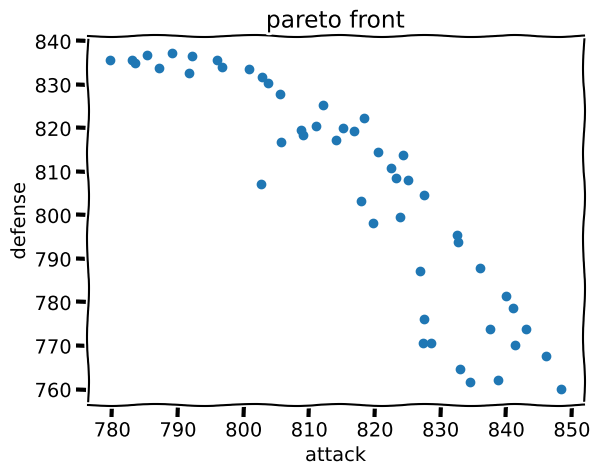

In [9]:
F = result.F
G = result.G

feasible = np.where(G[:,0]<=0)[0]
F_feas = F[feasible]

plt.xkcd()
plt.scatter(-F_feas[:,1],-F_feas[:,2])
plt.xlabel("attack")
plt.ylabel("defense")
plt.title("pareto front")

Total solutions: 50
Feasible solutions: 50
First front solutions: 50


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

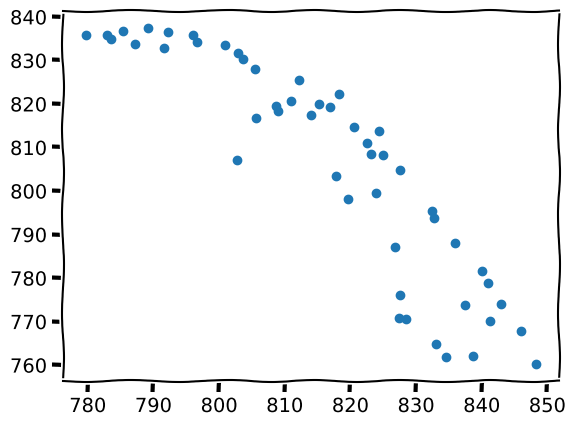

In [10]:
# After running NSGA-II
print(f"Total solutions: {len(F)}")
print(f"Feasible solutions: {np.sum(G[:,0]<=0)}")

# Get only the first front (Rank 1)
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Assuming F_feas is your feasible solutions' objectives
nds = NonDominatedSorting()
front_indices = nds.do(F_feas, only_non_dominated_front=True)

print(f"First front solutions: {len(front_indices)}")

# Now plot ONLY first front
F_first_front = F_feas[front_indices]
plt.scatter(-F_first_front[:,1], -F_first_front[:,2])

In [11]:
# After NSGA-II finishes, you have:
# - X: decision variables (population solutions, each is a team)
# - F: objective values (overall, attack, defense, etc.)
# - G: constraint violations (budget constraint)

# Extract costs for each team in the population
def get_team_cost(solution, player_data):
    """
    solution: array of player indices [gk_idx, p1_idx, p2_idx, ...]
    player_data: your dataframe with salary column
    """
    total_cost = sum(player_data.iloc[int(idx)]['wage'] for idx in solution)
    return total_cost

# # For all solutions in final population
# total_costs = []
# for solution in X:  # X is your final population's decision variables
#     cost = get_team_cost(solution, your_player_df)
#     total_costs.append(cost)

total_costs = np.array(total_cost)
total_cost

[2382000,
 1766000,
 1607000,
 1752000,
 2122000,
 2197000,
 1534000,
 2602000,
 1879000,
 2680000,
 2074000,
 2092000,
 2360000,
 1862000,
 2087000,
 2039000,
 1634000,
 2402000,
 2082000,
 2650000,
 2172000,
 1942000,
 2067000,
 1865000,
 1929000,
 1769000,
 1733000,
 2029000,
 1544000,
 1549000,
 2597000,
 2097000,
 1999000,
 1969000,
 1954000,
 1994000,
 2162000,
 2072000,
 1850000,
 2052000,
 1529000,
 1709000,
 1992000,
 2310000,
 1697000,
 2059000,
 1572000,
 2019000,
 1984000,
 1737000]

Text(0.5, 1.0, 'Pareto Front: Attack vs Defense (colored by cost)')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

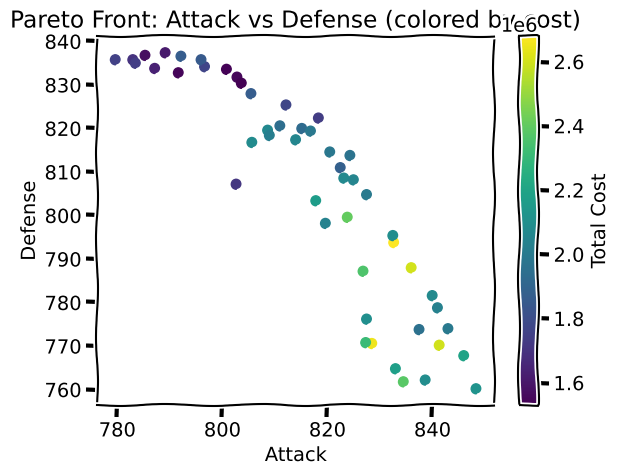

In [ ]:
# Plot 1: Attack vs Defense, colored by cost
plt.scatter(-F_first_front[:,1], -F_first_front[:,2], 
            c=total_costs, cmap='viridis')
plt.colorbar(label='Total Cost')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.title('Pareto Front: Attack vs Defense (colored by cost)')


Text(0.5, 1.0, 'Pareto Front: Quality vs Cost')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

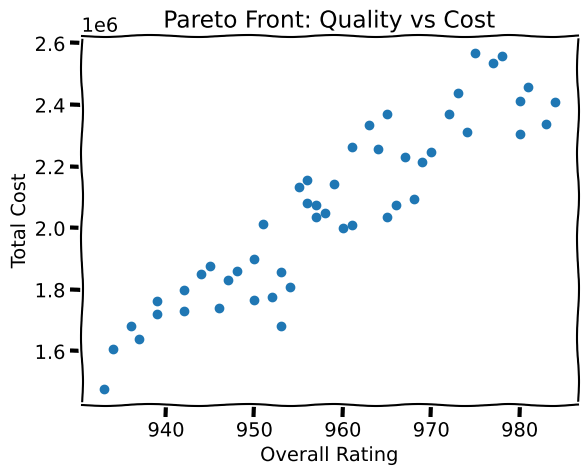

In [ ]:

# Plot 2: Overall vs Cost (this is probably your REAL Pareto front)
plt.scatter(-F_first_front[:,0], total_costs)
plt.xlabel('Overall Rating')
plt.ylabel('Total Cost')
plt.title('Pareto Front: Quality vs Cost')


Text(0.5, 1.0, 'True Pareto Front: Quality vs Cost')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

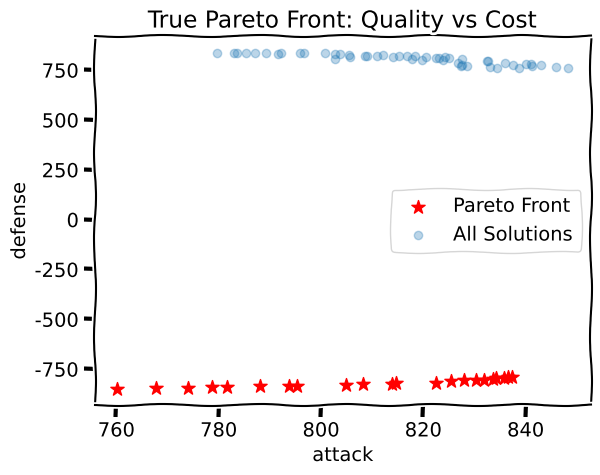

In [13]:
# Get only non-dominated solutions (Pareto front)
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Assuming you're looking at overall rating vs cost
# Create a 2D objective space: [overall_rating, cost]
# But we want to MINIMIZE cost, so negate overall rating for minimization
objectives_for_pareto = np.column_stack([
    F_first_front[:, 1],  # Negative overall (to minimize)
    F_first_front[:,2]  # Cost (to minimize)
])

nds = NonDominatedSorting()
pareto_indices = nds.do(objectives_for_pareto, only_non_dominated_front=True)

# Plot only Pareto front
pareto_costs = F_first_front[pareto_indices,1]
pareto_overall = F_first_front[pareto_indices, 2]


plt.scatter(-pareto_overall, pareto_costs, s=100, c='red', marker='*', label='Pareto Front')
plt.scatter(-F_first_front[:, 1], -F_first_front[:,2], alpha=0.3, label='All Solutions')
plt.xlabel('attack')
plt.ylabel('defense')
plt.legend()
plt.title('True Pareto Front: Quality vs Cost')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

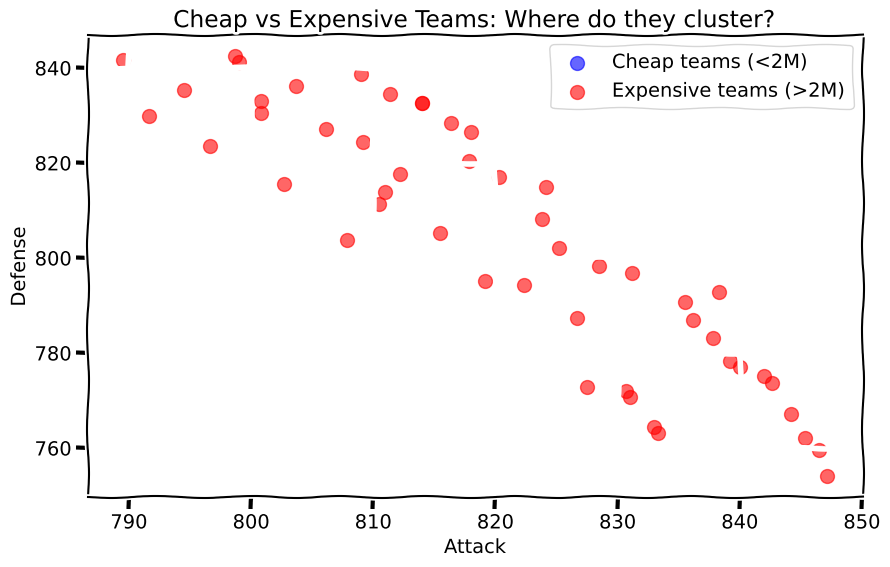

In [ ]:
# Find the most expensive teams and see where they lie
expensive_mask = total_costs > 4.5e5  # top 10% by cost
cheap_mask = total_costs < 4.5e5     # bottom 10% by cost

plt.figure(figsize=(10, 6))
plt.scatter(-F[cheap_mask, 1], -F[cheap_mask, 2], 
            c='blue', label='Cheap teams (<2M)', alpha=0.6, s=100)
plt.scatter(-F[expensive_mask, 1], -F[expensive_mask, 2], 
            c='red', label='Expensive teams (>2M)', alpha=0.6, s=100)
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.legend()
plt.title('Cheap vs Expensive Teams: Where do they cluster?')
plt.grid(True)

Text(0.5, 0, 'Defense')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.


findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not fo

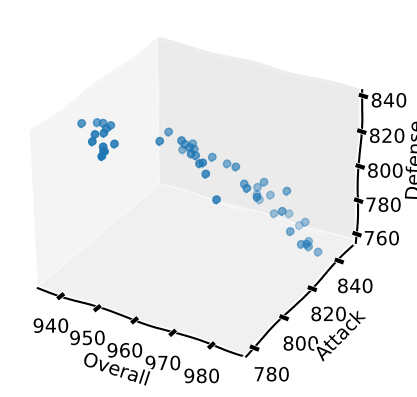

In [14]:
# Plot 3: 3D plot - the TRUE Pareto front in 3 objectives
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(-F_first_front[:,0], -F_first_front[:,1], -F_first_front[:,2])
ax.set_xlabel('Overall')
ax.set_ylabel('Attack')
ax.set_zlabel('Defense')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

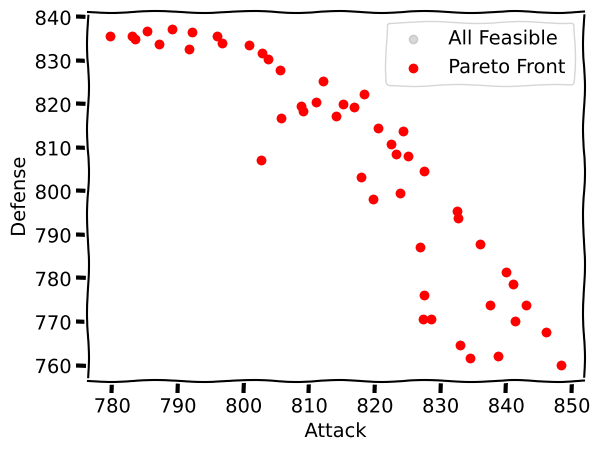

In [15]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# 1. Initialize the sorter
nds = NonDominatedSorting()

# 2. Get all fronts (fronts[0] is the Pareto Front)
fronts = nds.do(F_feas)
pareto_indices = fronts[0]

# 3. Filter your feasible results
F_pareto = F_feas[pareto_indices]

# 4. Plot
plt.scatter(-F_feas[:, 1], -F_feas[:, 2], alpha=0.3, color='gray', label='All Feasible')
plt.scatter(-F_pareto[:, 1], -F_pareto[:, 2], color='red', label='Pareto Front')
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.legend()
plt.show()

In [16]:
np.corrcoef(-F.T)


array([[ 1.        ,  0.76895878, -0.89962434],
       [ 0.76895878,  1.        , -0.8976601 ],
       [-0.89962434, -0.8976601 ,  1.        ]])

In [17]:
from src.create_pitch import plot_team

df=df.rename(columns={'Assigned role':'role'})
df_dict = df.to_dict(orient='records')

In [18]:
df

,Name,Position,Overall,role,Wage,attack,defense
0,M. Neuer,{'GK': 'GK'},90,GK,72000,42.000000,38.2
1,Marquinhos,{'CB': 'DF'},88,CB,170000,73.333333,87.2
2,V. van Dijk,{'CB': 'DF'},90,CB,230000,70.000000,85.2
3,A. Robertson,{'LB': 'DF'},87,LB,185000,77.000000,86.0
4,João Cancelo,"{'RB': 'DF', 'LB': 'DF'}",88,RB,250000,83.000000,86.4
5,F. de Jong,{'CM': 'MF'},87,CM,230000,82.166667,84.6
6,N. Kanté,"{'CM': 'MF', 'CDM': 'MF'}",89,CDM,220000,75.833333,87.0
7,L. Goretzka,"{'CM': 'MF', 'CDM': 'MF'}",87,CM,115000,84.166667,85.2
8,J. Gallardo,"{'LW': 'FW', 'LB': 'DF', 'LM': 'MF'}",75,LW,0,72.833333,74.2
9,F. Valverde,"{'CM': 'MF', 'RW': 'FW'}",84,RW,175000,79.833333,82.4


findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

50
            Name                   Position  Overall role    Wage     attack  \
0       J. Oblak               {'GK': 'GK'}       89   GK  100000  33.666667   
1    V. van Dijk               {'CB': 'DF'}       90   CB  230000  70.000000   
2     Marquinhos               {'CB': 'DF'}       88   CB  170000  73.333333   
3   T. Hernández  {'LWB': 'DF', 'LB': 'DF'}       85   LB   82000  80.666667   
4   João Cancelo   {'RB': 'DF', 'LB': 'DF'}       88   RB  250000  83.000000   
5       L. Messi  {'CAM': 'MF', 'RW': 'FW'}       91  CAM  195000  90.500000   
6     J. Kimmich  {'CDM': 'MF', 'RB': 'DF'}       89  CDM  130000  80.333333   
7   K. De Bruyne  {'CM': 'MF', 'CAM': 'MF'}       91  CAM  350000  87.166667   
8      K. Mbappé   {'ST': 'FW', 'LW': 'FW'}       91   LW  230000  90.333333   
9       L. Messi  {'CAM': 'MF', 'RW': 'FW'}       91   RW  195000  90.500000   
10    K. Benzema   {'CF': 'FW', 'ST': 'FW'}       91   CF  450000  88.666667   

    defense  
0      35.2  
1      8

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

            Name                               Position  Overall role    Wage  \
0    T. Courtois                           {'GK': 'GK'}       90   GK  250000   
1     Marquinhos                           {'CB': 'DF'}       88   CB  170000   
2       D. Alaba                           {'CB': 'DF'}       86   CB  220000   
3       M. Acuña                           {'LB': 'DF'}       85   LB   46000   
4   João Cancelo               {'RB': 'DF', 'LB': 'DF'}       88   RB  250000   
5     F. de Jong                           {'CM': 'MF'}       87   CM  230000   
6    L. Goretzka              {'CM': 'MF', 'CDM': 'MF'}       87  CDM  115000   
7       N. Kanté              {'CM': 'MF', 'CDM': 'MF'}       89  CDM  220000   
8    J. Gallardo   {'LW': 'FW', 'LB': 'DF', 'LM': 'MF'}       75   LW       0   
9    F. Valverde               {'CM': 'MF', 'RW': 'FW'}       84   RW  175000   
10     C. Nkunku  {'CF': 'FW', 'ST': 'FW', 'CAM': 'MF'}       86   CF   90000   

       attack  defense  
0 

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.


            Name                               Position  Overall role    Wage  \
0       M. Neuer                           {'GK': 'GK'}       90   GK   72000   
1     Marquinhos                           {'CB': 'DF'}       88   CB  170000   
2    V. van Dijk                           {'CB': 'DF'}       90   CB  230000   
3   A. Robertson                           {'LB': 'DF'}       87   LB  185000   
4   João Cancelo               {'RB': 'DF', 'LB': 'DF'}       88   RB  250000   
5     F. de Jong                           {'CM': 'MF'}       87   CM  230000   
6     J. Kimmich              {'CDM': 'MF', 'RB': 'DF'}       89  CDM  130000   
7       N. Kanté              {'CM': 'MF', 'CDM': 'MF'}       89   CM  220000   
8    J. Gallardo   {'LW': 'FW', 'LB': 'DF', 'LM': 'MF'}       75   LW       0   
9    F. Valverde               {'CM': 'MF', 'RW': 'FW'}       84   RW  175000   
10     C. Nkunku  {'CF': 'FW', 'ST': 'FW', 'CAM': 'MF'}       86   CF   90000   

       attack  defense  
0 

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

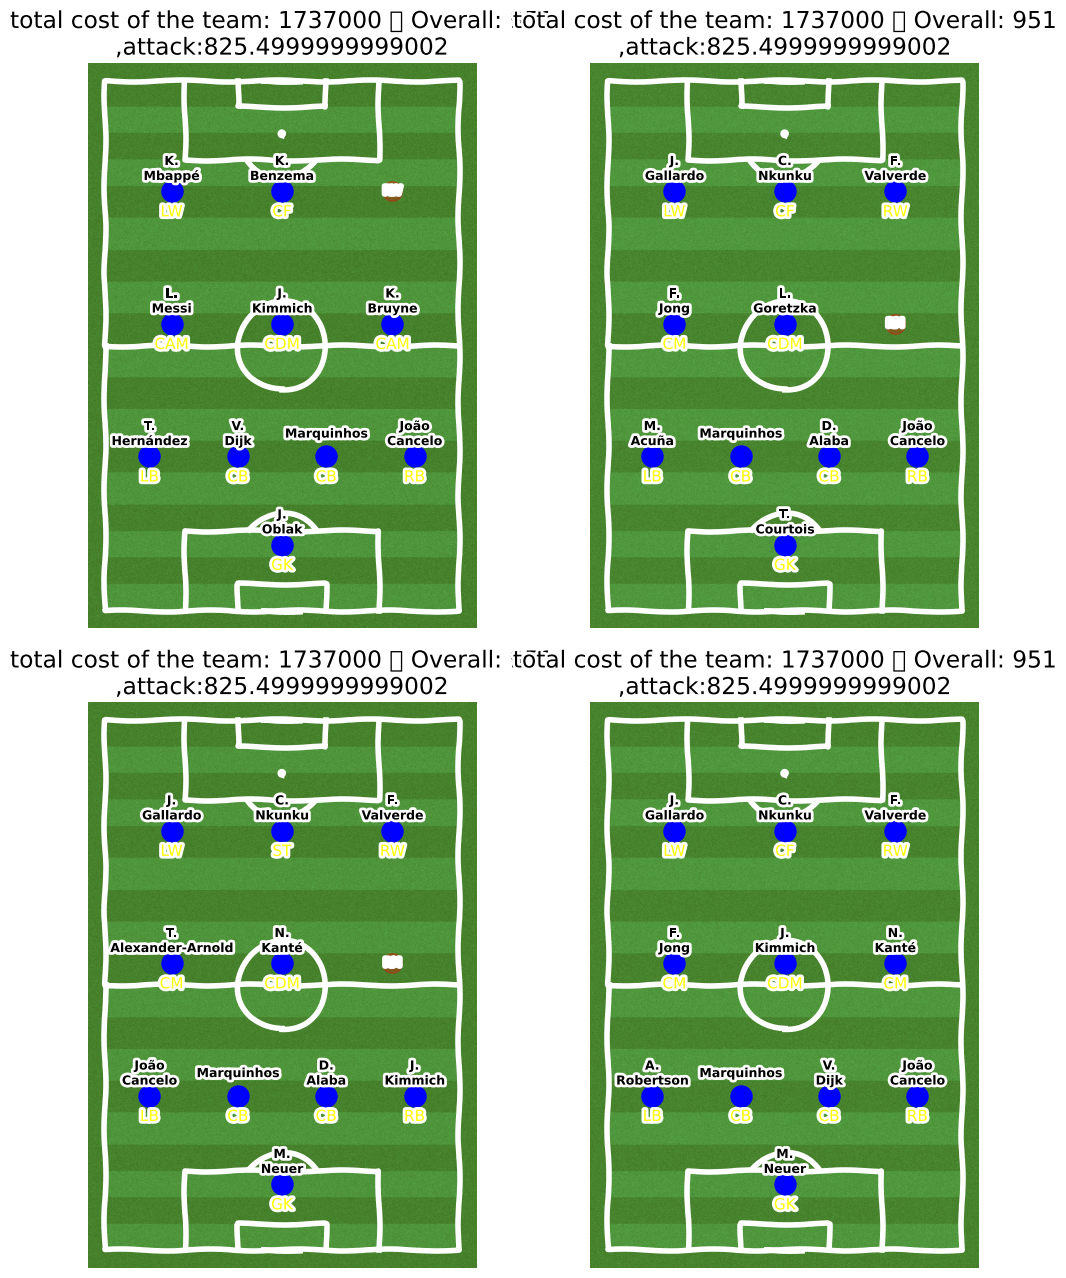

In [19]:


fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(12,13))
print(len(dfs))

for idx,df_ in enumerate(dfs[:4]):
    df_dict = df_.to_dict(orient='records')
    print(df_)
    nrow = idx // 2
    ncol = idx % 2
    print(ncol,nrow)
    plot = plot_team(df_dict,ax[nrow,ncol])
    ax[nrow,ncol].set_title(f"total cost of the team: {sum(df['Wage'])} \t Overall: {sum(df['Overall'])}\n,attack:{sum(df['attack'])}")

    